In [1]:
!pip install numpy scipy matplotlib plotly -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import sph_harm_y, eval_genlaguerre, factorial

from mpl_toolkits.mplot3d import Axes3D

print("Quantum environment ready.")

Quantum environment ready.


In [3]:
# Bohr yarıçapı
a0 = 1.0

# 3D uzay
N = 120
extent = 6.0

x = np.linspace(-extent, extent, N)
y = np.linspace(-extent, extent, N)
z = np.linspace(-extent, extent, N)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

R = np.sqrt(X**2 + Y**2 + Z**2)

# Hydrogen 1s wavefunction
psi_1s = (
    1 / np.sqrt(np.pi * a0**3)
    * np.exp(-R / a0)
)

# Probability density
density_1s = np.abs(psi_1s)**2

print("Maximum probability density:", density_1s.max())

Maximum probability density: 0.26729817818314155


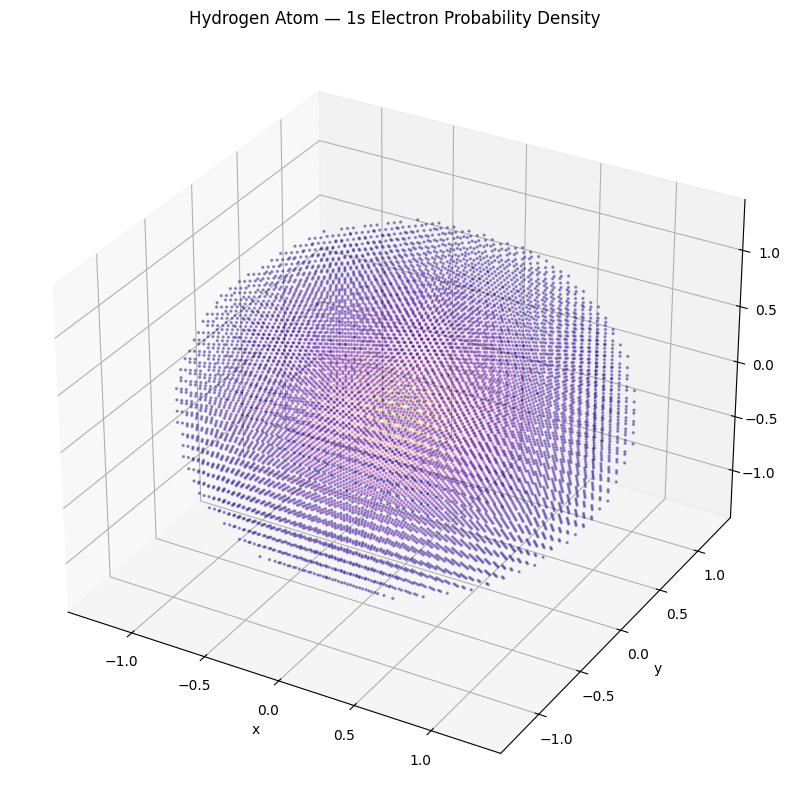

In [4]:
# Yoğunluğu belirli bir eşikten yüksek olan noktaları seç
threshold = density_1s.max() * 0.08

mask = density_1s > threshold

x_points = X[mask]
y_points = Y[mask]
z_points = Z[mask]
density_points = density_1s[mask]

# Çok fazla nokta varsa rastgele azalt
max_points = 30000

if len(x_points) > max_points:
    idx = np.random.choice(len(x_points), max_points, replace=False)

    x_points = x_points[idx]
    y_points = y_points[idx]
    z_points = z_points[idx]
    density_points = density_points[idx]

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_points,
    y_points,
    z_points,
    c=density_points,
    cmap="plasma",
    s=2,
    alpha=0.35
)

ax.set_title("Hydrogen Atom — 1s Electron Probability Density")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

In [5]:
# 2p_z orbitalinin basitleştirilmiş hidrojen dalga fonksiyonu

r = R

# Normalizasyon katsayısı
normalization = 1 / (4 * np.sqrt(2 * np.pi * a0**5))

# cos(theta) = z/r
cos_theta = np.divide(
    Z,
    R,
    out=np.zeros_like(R),
    where=R != 0
)

psi_2pz = (
    normalization
    * r
    * np.exp(-r / (2 * a0))
    * cos_theta
)

density_2pz = np.abs(psi_2pz)**2

print("2p orbital calculated.")

2p orbital calculated.


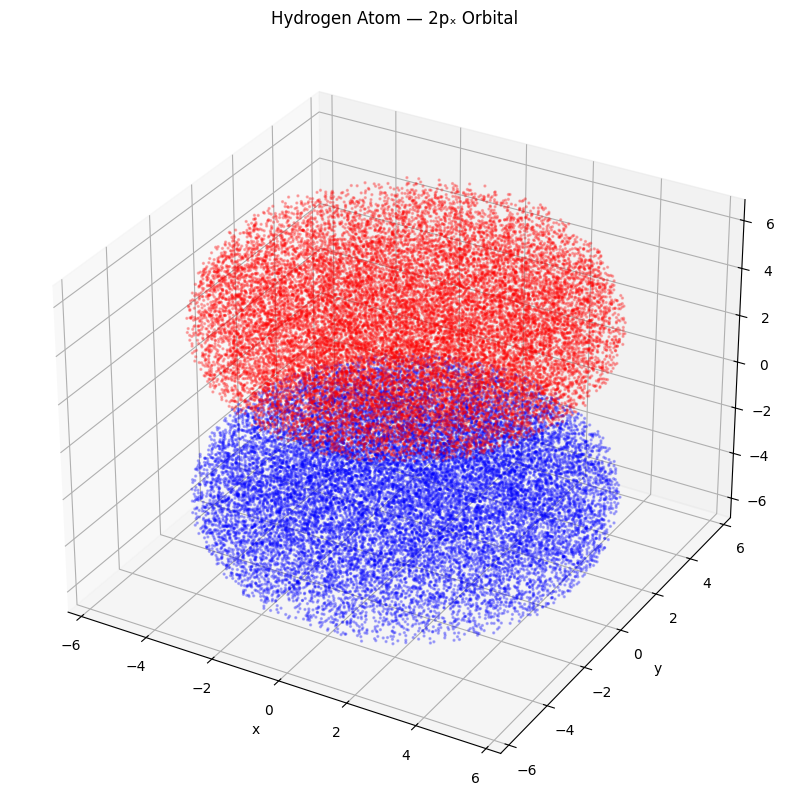

In [6]:
threshold = density_2pz.max() * 0.03

mask = density_2pz > threshold

xp = X[mask]
yp = Y[mask]
zp = Z[mask]

# Dalga fonksiyonunun işareti
sign = np.sign(psi_2pz[mask])

# Nokta sayısını sınırla
max_points = 40000

if len(xp) > max_points:
    idx = np.random.choice(len(xp), max_points, replace=False)

    xp = xp[idx]
    yp = yp[idx]
    zp = zp[idx]
    sign = sign[idx]

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection="3d")

# Pozitif ve negatif loblar
positive = sign > 0
negative = sign < 0

ax.scatter(
    xp[positive],
    yp[positive],
    zp[positive],
    c="red",
    s=2,
    alpha=0.25
)

ax.scatter(
    xp[negative],
    yp[negative],
    zp[negative],
    c="blue",
    s=2,
    alpha=0.25
)

ax.set_title("Hydrogen Atom — 2pₓ Orbital")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()

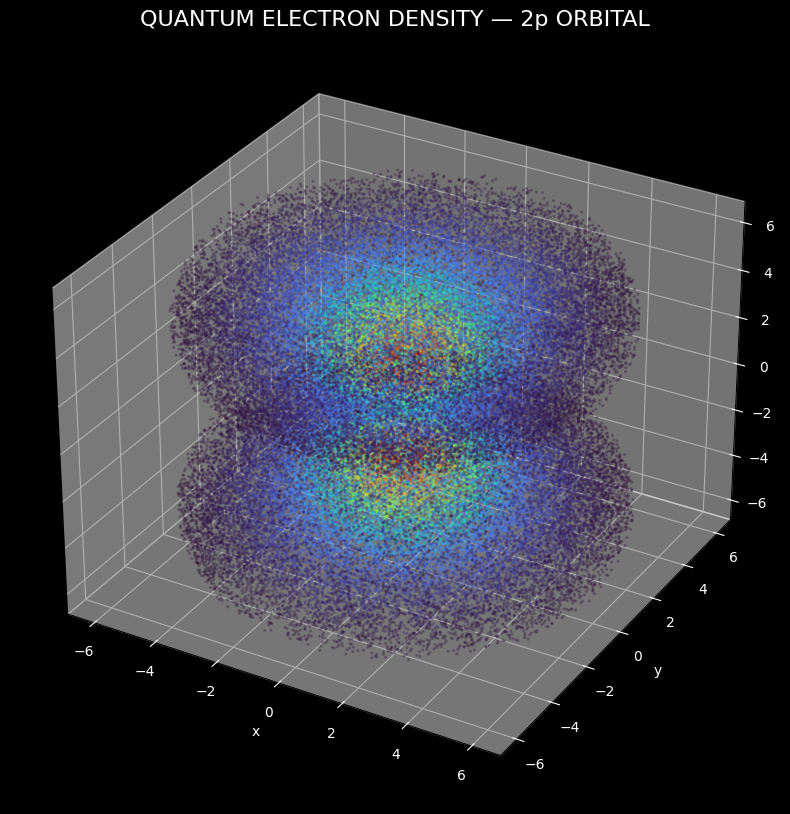

In [7]:
fig = plt.figure(figsize=(12, 10))

ax = fig.add_subplot(111, projection="3d")

density = np.abs(psi_2pz)**2

threshold = density.max() * 0.015

mask = density > threshold

xp = X[mask]
yp = Y[mask]
zp = Z[mask]

values = density[mask]

# Çok fazla noktayı azalt
max_points = 60000

if len(xp) > max_points:

    idx = np.random.choice(
        len(xp),
        max_points,
        replace=False
    )

    xp = xp[idx]
    yp = yp[idx]
    zp = zp[idx]
    values = values[idx]

ax.scatter(
    xp,
    yp,
    zp,
    c=values,
    cmap="turbo",
    s=1.8,
    alpha=0.25
)

ax.set_facecolor("black")
fig.patch.set_facecolor("black")

ax.set_title(
    "QUANTUM ELECTRON DENSITY — 2p ORBITAL",
    color="white",
    fontsize=16
)

ax.set_xlabel("x", color="white")
ax.set_ylabel("y", color="white")
ax.set_zlabel("z", color="white")

ax.tick_params(colors="white")

plt.show()

In [8]:
# Büyük miktarda rastgele örnek üret
num_samples = 250000

# Rastgele koordinatlar
samples = np.random.normal(
    loc=0,
    scale=1.5,
    size=(num_samples, 3)
)

xs = samples[:, 0]
ys = samples[:, 1]
zs = samples[:, 2]

rs = np.sqrt(xs**2 + ys**2 + zs**2)

# Hidrojen 1s yoğunluğu
probability = np.exp(-2 * rs)

# Olasılığa göre örnek seç
random_values = np.random.random(num_samples)

mask = random_values < probability

xs = xs[mask]
ys = ys[mask]
zs = zs[mask]

# Maksimum görüntü noktası
max_points = 50000

if len(xs) > max_points:

    idx = np.random.choice(
        len(xs),
        max_points,
        replace=False
    )

    xs = xs[idx]
    ys = ys[idx]
    zs = zs[idx]

print("Electron cloud points:", len(xs))

Electron cloud points: 9018


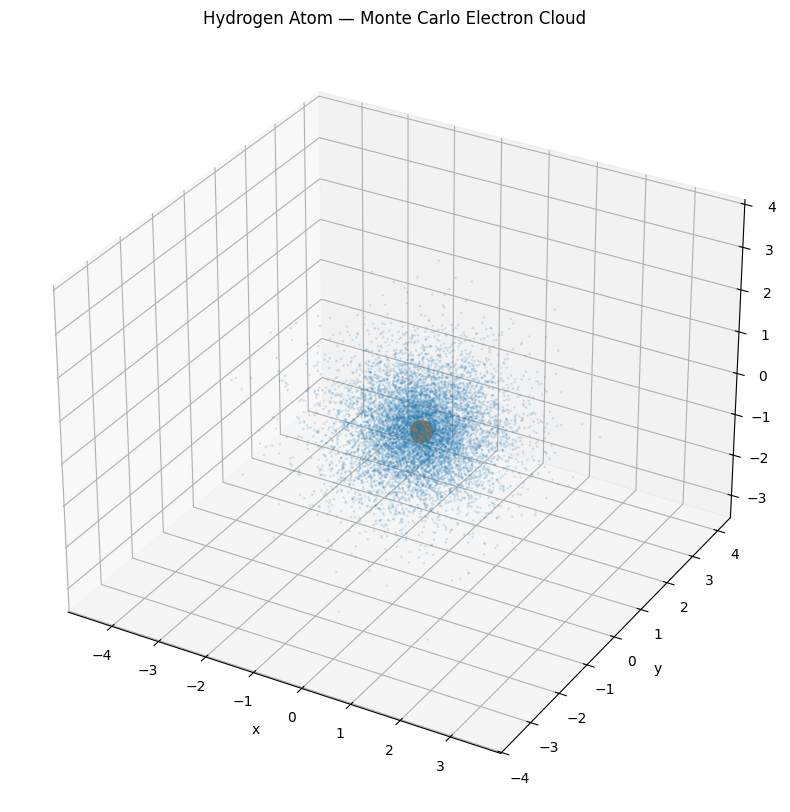

In [9]:
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    xs,
    ys,
    zs,
    s=1,
    alpha=0.12
)

ax.scatter(
    [0],
    [0],
    [0],
    s=250,
    marker="o"
)

ax.set_title(
    "Hydrogen Atom — Monte Carlo Electron Cloud"
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()